
# 2 &mdash; What a covariance target can do that an $S$ target cannot

* **B.3** directional squeezed source &mdash; asymmetry *between* the port blocks
  at finite cooperativity, enforced together with a transmission pin so the
  minimal device stays connected (Sec. 11).
* **B.4** broadband squeezer &mdash; point + $\Omega$-derivative pins *and* a
  pinned band, read in units of the device's own linewidth ($\tilde\kappa
  \equiv 1$) at a finite pump budget. Both anchors are part of the target:
  without them it is scale-degenerate and a single pumped mode satisfies it
  (App. A.4(c)).

Script version: `examples/02_directional_and_spectral.py`.


In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from autogaussian import (
    CovarianceArchitectureOptimizer,
    plot_graph,
    plot_list_of_graphs,
    solution_table,
    variance_to_dB,
)
from autogaussian.constraints import CooperativityBudget
from autogaussian.gallery import broadband_squeezer, directional_squeezed_source


## B.3 &mdash; directional squeezed source

How many auxiliary modes are needed? Sec. 6(a): grow the auxiliary count until
the fully connected graph works. Two directly coupled modes cannot be made
directional by any coupling phase alone (mode-swap symmetry), so 0 auxiliaries
**must** fail here.

In [3]:
problem = directional_squeezed_source(variance=0.2, forward_transmission=1.3,
                                      isolate_backward=True)

optimizer = None
for num_auxiliary_modes in (0, 1):
    candidate = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=3,
        make_initial_test=False, kwargs_optimization={"num_tests": 30},
        **problem.optimizer_kwargs())
    success, infos = candidate.test_graph(candidate.space.fully_connected())
    print("  %i auxiliary modes: %-8s best loss %.2g"
          % (num_auxiliary_modes, "VALID" if success else "INVALID",
             min(info["loss_reached"] for info in infos)))
    if success:
        optimizer = candidate
        break

  0 auxiliary modes: INVALID  best loss 0.27


  1 auxiliary modes: VALID    best loss 9.5e-11


In [4]:
x = infos[-1]["x"]
V = np.real(optimizer.oracle.covariance(x, 0.0))
S, _ = optimizer.oracle.scattering(x, 0.0)

print("port covariance at Omega = 0:")
print(np.round(V, 4))
print("\nport 1 (vacuum target): diag = %.4f, %.4f" % (V[0, 0], V[1, 1]))
print("port 2 squeezing:       %.2f dB  (variance %.4f)"
      % (variance_to_dB(V[2, 2]), V[2, 2]))
print("transport: forward |S_10|^2 = %.3f, backward |S_01|^2 = %.3f"
      % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: max Re eig(M~) = %.3f" % infos[-1]["max_real_eigenvalue"])

port covariance at Omega = 0:
[[ 1.0e+00  0.0e+00 -1.2e-03  2.6e-03]
 [ 0.0e+00  1.0e+00  5.0e-04  5.9e-03]
 [-1.2e-03  5.0e-04  2.0e-01  0.0e+00]
 [ 2.6e-03  5.9e-03  0.0e+00  5.0e+00]]

port 1 (vacuum target): diag = 1.0000, 1.0000
port 2 squeezing:       6.99 dB  (variance 0.2000)
transport: forward |S_10|^2 = 1.300, backward |S_01|^2 = 0.000
stability margin: max Re eig(M~) = -0.011



### Which elements does the solution actually need?

A full breadth-first search over this lattice is expensive &mdash; 3 modes give 12
slots, i.e. $3^{12} \approx 5\cdot10^5$ graphs, and every verdict costs up to 30
restarts. `greedy_minimal_subgraph` is the cheap descent instead: weaken one slot
at a time for as long as the graph stays valid. It returns *a* minimal device (not
the complete irreducible set &mdash; that is `minimal_valid_subgraphs`), which is
enough to see what directionality really requires.

In [5]:
minimal = optimizer.greedy_minimal_subgraph(optimizer.space.fully_connected(),
                                            num_tests=10, verbose=True)
print("\na minimal setup: %s" % ", ".join(optimizer.space.describe(minimal)))

solution = optimizer.solution_of(minimal)
if solution is None:
    success_min, infos_min = optimizer.test_graph(minimal, num_tests=30)
    solution = infos_min[-1]

V = np.real(optimizer.oracle.covariance(solution["x"], 0.0))
S, _ = optimizer.oracle.scattering(solution["x"], 0.0)
print("port 1 = [%.4f, %.4f] (vacuum)   port 2 = %.4f (%.2f dB)"
      % (V[0, 0], V[1, 1], V[2, 2], variance_to_dB(V[2, 2])))
print("transport: forward %.3f   backward %.3f"
      % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: %.4f" % solution["max_real_eigenvalue"])

report = optimizer.param.physical_report(solution["x"])
for section in ("cooperativities", "phases", "detunings", "decay_ratios"):
    if report[section]:
        print("\n%s:" % section)
        for key, value in report[section].items():
            print("   %-16s %.4f" % (key, value))

   -> beam-splitter 0-1 (complex), beam-splitter 0-2 (complex), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (complex), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


...

   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 0-2 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (real)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex)



a minimal setup: beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex)
port 1 = [1.0000, 1.0000] (vacuum)   port 2 = 0.2000 (6.99 dB)
transport: forward 1.300   backward 0.000
stability margin: -0.4993

cooperativities:
   C^{BS}_{0,1}     0.5614
   C^{SQZ}_{0,1}    0.2487
   C^{BS}_{0,2}     0.3097
   C^{BS}_{1,2}     1.8125
   C^{SQZ}_{1,2}    0.8079

phases:
   arg(g_{0,1})     0.0000
   arg(nu_{0,1})    0.0000
   arg(g_{0,2})     3.1416
   arg(g_{1,2})     -1.5708
   arg(nu_{1,2})    1.5708

decay_ratios:
   kappa~_0         1.0000
   kappa~_1         1.0000
   kappa~_2         1.0000


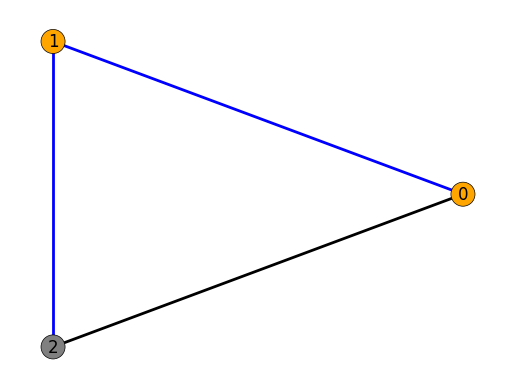

In [6]:
# modes 0, 1 are the ports (orange), mode 2 is the damped auxiliary (gray)
plot_graph(minimal, optimizer.space, ax=plt.gca(),
           node_colors=["orange", "orange", "gray"])
plt.show()


## B.4 &mdash; broadband squeezer

**Target.** $\sigma_{xx} = 0.5$ (3 dB), held flat across the cavity's *own*
full linewidth, by a device with a finite pump budget:

| | |
|---|---|
| depth | $\sigma_{xx} = 0.5$ |
| band | flat on $\lvert\Omega\rvert \le 0.5$, sampled at $0, \pm 0.1, \ldots, \pm 0.5$ |
| flatness at centre | $\sigma_{xx}' = \sigma_{xx}'' = 0$ at $\Omega = 0$ |
| frequency unit | $\tilde\kappa \equiv 1$, so $\Omega$ is read in linewidths |
| pump budget | $C \le 10$ |

The last two rows are not decoration &mdash; they are what makes the first three
mean anything.

The forward map sees $\Omega$ only through $\Omega/\tilde\kappa$ (App. A.4),
so $\tilde\kappa$ *is* a stretch factor on the frequency axis, sitting in the
parameter vector as a free variable. A flat target is invariant under that
stretch &mdash; a constant stretched is the same constant &mdash; so the pins
constrain the *shape* of the spectrum and say nothing about its *width*, which
is the entire content of the word "broadband". Left free, the optimiser runs
$\tilde\kappa$ to its bound and satisfies the band by making the linewidth far
wider than it: a single pumped mode, no auxiliary, no coupling.

Bounding $\tilde\kappa \equiv 1$ declares $\kappa_{\rm ref}$ to be the
device's own linewidth, so $\lvert\Omega\rvert \le 0.5$ becomes *flat across
my own FWHM* &mdash; a ratio between two frequencies that both belong to the
device, which no rescaling can dissolve. The cooperativity budget closes the
second escape: with the scale fixed the pumps run away instead ($C \sim 10^4$),
meeting the target at a limit point rather than with a device
(`CooperativityBudget`, Sec. 7.3).

Compare B.8, whose target names a crossover frequency. A named feature on the
$\Omega$ axis pins the stretch by itself, which is why only a *flat* target
needs the scale supplied from outside.


In [7]:
BANDWIDTH = 0.5   # in linewidths: |Omega| <= 0.5 is one full FWHM band
BUDGET = 10.0     # cooperativity cap -- a device, not a C -> infinity limit point

problem = broadband_squeezer(variance=0.5, num_derivatives=2,
                             bandwidth=BANDWIDTH, num_band_points=10)
print(problem.target)

# the two scale anchors discussed above
anchors = dict(log_decay_ratio_bound=np.log(1.01),                  # kappa~ == 1
               constraints=(CooperativityBudget(maximum=BUDGET),))

optimizer_bb = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    kwargs_optimization={"num_tests": 40}, **problem.optimizer_kwargs(**anchors))

success, infos_bb = optimizer_bb.test_graph(optimizer_bb.space.fully_connected())
print("fully connected graph:", "VALID" if success else "INVALID",
      " loss %.2g" % infos_bb[-1]["loss_reached"])

CovarianceTarget(broadband squeezer, 1 ports, 13 pins)
  sigma_out[0,0](Omega=0) = 0.5   (w=1, full)
  d^1/dOmega^1 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  d^2/dOmega^2 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[0,0](Omega=-0.5) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.4) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.3) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.2) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.1) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.1) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.2) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.3) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.4) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.5) = (0.5+0j)   (w=1, full)


fully connected graph: VALID  loss 8.6e-11



### What the anchors buy

The same 13 pins, tested twice on the *smallest possible* graph: on-site
squeezing on the port mode and nothing else. Unanchored it passes &mdash; by
running $\tilde\kappa$ to its bound until the pinned "band" is half a percent
of the linewidth.


In [ ]:
SINGLE_MODE = np.array([0, 0, 0, 2, 0, 0], dtype="int8")   # on-site squeezing on the port only

for label, extra in [("unanchored (kappa~ <= 100, no budget)", {}),
                     ("anchored   (kappa~ == 1, C <= %g)" % BUDGET, anchors)]:
    trial = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
        kwargs_optimization={"num_tests": 40}, **problem.optimizer_kwargs(**extra))
    ok, infos = trial.test_graph(SINGLE_MODE)
    kappa = trial.param.physical_report(infos[-1]["x"])["decay_ratios"]["kappa~_0"]
    print("%-38s %-8s loss %.1e   kappa~_0 = %6.1f   band = %.3f linewidths"
          % (label, "VALID" if ok else "INVALID", infos[-1]["loss_reached"],
             kappa, BANDWIDTH / kappa))

unanchored (kappa~ <= 100, no budget)  VALID    loss 9.5e-11   kappa~_0 =  100.0   band = 0.005 linewidths


anchored   (kappa~ == 1, C <= 10)      INVALID  loss 1.9e-05   kappa~_0 =    1.0   band = 0.505 linewidths


decay ratios:    {'kappa~_0': 1.01, 'kappa~_1': 0.9901}
cooperativities: {'C_{0,0}': 1.863, 'C^{BS}_{0,1}': 9.255, 'C^{SQZ}_{0,1}': 1.491, 'C_{1,1}': 8.292}
max |sigma_xx - 0.5| across the band: 1.60e-05


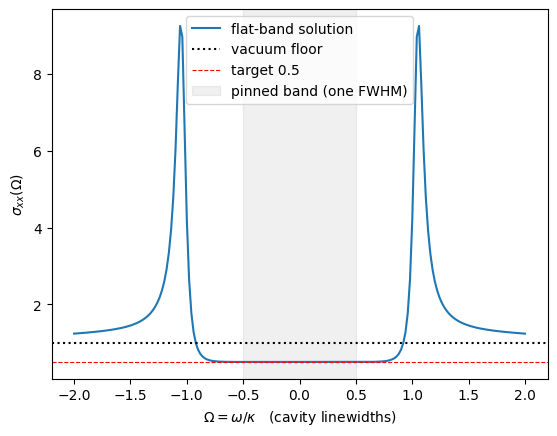

In [ ]:
x_bb = infos_bb[-1]["x"]
omegas = np.linspace(-2.0, 2.0, 201)
spectrum = np.array([np.real(optimizer_bb.oracle.covariance(x_bb, w)[0, 0])
                     for w in omegas])

report = optimizer_bb.param.physical_report(x_bb)
print("decay ratios:   ", {k: round(v, 4) for k, v in report["decay_ratios"].items()})
print("cooperativities:", {k: round(v, 3) for k, v in report["cooperativities"].items()})
in_band = np.abs(omegas) <= BANDWIDTH
print("max |sigma_xx - 0.5| across the band: %.2e"
      % np.max(np.abs(spectrum[in_band] - 0.5)))

plt.plot(omegas, spectrum, "-", label="flat-band solution")
plt.axhline(1.0, color="k", ls=":", label="vacuum floor")
plt.axhline(0.5, color="r", ls="--", lw=0.8, label="target 0.5")
plt.axvspan(-BANDWIDTH, BANDWIDTH, color="k", alpha=0.06, label="pinned band (one FWHM)")
plt.xlabel(r"$\Omega = \omega/\kappa$   (cavity linewidths)")
plt.ylabel(r"$\sigma_{xx}(\Omega)$")
plt.legend()
plt.show()


### The full search for B.4

2 modes give 6 slots, i.e. $3^6 = 729$ graphs, so the complete Sec. 6 loop is
affordable &mdash; but it is no longer *quick*. Under the anchored target most
graphs are invalid, and invalid is the expensive verdict: every rejection is
escalated to more restarts before it is recorded. At `num_tests = 8` the run
below took about 7 minutes and 4800 oracle calls (17 valid, 296 invalid); it
prints its own elapsed time.

The price of `num_tests = 8` is accuracy, and here it is steep: 295 of the 296
rejections are *uncertified*, i.e. the oracle failed to find a parameter point
rather than proving none exists. $W = 0.5$ sits close to the feasibility
frontier at $C \le 10$ (the fully connected graph reaches $W \approx 0.54$),
so a thin margin plus few restarts means some of those graphs are valid and
were missed &mdash; and a missed valid graph can hide a *simpler* irreducible
device than the ones listed. Treat the list below as indicative, not as the
irreducible set. To harden it: raise `num_tests`, or run at `BUDGET = 100` and
re-test the survivors at 10. The one result that does not depend on this is the
single-mode graph, which was tested directly above at 40 restarts and fails.


In [10]:
import time

optimizer_search = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    kwargs_optimization={"num_tests": 8}, **problem.optimizer_kwargs(**anchors))

t0 = time.time()
irreducibles_bb = optimizer_search.perform_breadth_first_search(progress=False)
print("search finished in %.0f s" % (time.time() - t0))

print("%i irreducible graphs (%i oracle calls)"
      % (len(irreducibles_bb), sum(optimizer_search.num_tested_graphs)))
for graph in sorted(irreducibles_bb, key=lambda g: int(np.sum(g))):
    print("   complexity %i:  %s"
          % (int(np.sum(graph)), ", ".join(optimizer_search.space.describe(graph))))
print()
print(optimizer_search.report())

start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


test 70 graphs with 5 degrees of freedom:


test 61 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 37 graphs with 3 degrees of freedom:


test 15 graphs with 2 degrees of freedom:


test 3 graphs with 1 degrees of freedom:
valid: 17    invalid: 296 (certified 1, uncertified 295)    oracle calls: 4812    escalations: 299
optimisation finished, list of irreducible graphs has 7 elements (295 uncertified rejections)
search finished in 423 s
7 irreducible graphs (313 oracle calls)
   complexity 7:  detuning Delta_0, beam-splitter 0-1 (real), on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)
   complexity 7:  detuning Delta_0, beam-splitter 0-1 (real), detuning Delta_1, on-site squeezing 0 (complex), on-site squeezing 1 (complex)
   complexity 7:  detuning Delta_0, beam-splitter 0-1 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (real)
   complexity 7:  detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (complex), on-site squeezing 1 (real)
   complexity 8:  beam-splitter 0-1 (real), detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing

Every irreducible broadband device with its converged parameters.


In [11]:
print(solution_table(optimizer_search, irreducibles_bb, limit=6))


7 valid graph(s), with the converged parameters:

#0  complexity=7  couplings=4  pumps=3
      detuning Delta_0
      beam-splitter 0-1 (real)
      on-site squeezing 0 (complex)
      two-mode squeezing 0-1 (real)
      on-site squeezing 1 (complex)
      loss=9.73e-11   max Re eig(M~)=-0.0149
      cooperativities:
         C_{0,0}              +4.0203
         C^{BS}_{0,1}         +8.6372
         C^{SQZ}_{0,1}        +0.1659
         C_{1,1}              +8.8467
      phases:
         arg(nu_{0,0})        +0.6750
         arg(nu_{0,1})        +3.1416
         arg(nu_{1,1})        +1.7589
      detunings:
         Delta_0/kappa_0      -0.9502
      decay_ratios:
         kappa~_0             +1.0100
         kappa~_1             +0.9901

#1  complexity=7  couplings=3  pumps=2
      detuning Delta_0
      beam-splitter 0-1 (real)
      detuning Delta_1
      on-site squeezing 0 (complex)
      on-site squeezing 1 (complex)
      loss=9.79e-11   max Re eig(M~)=-0.4948
      cooperativ

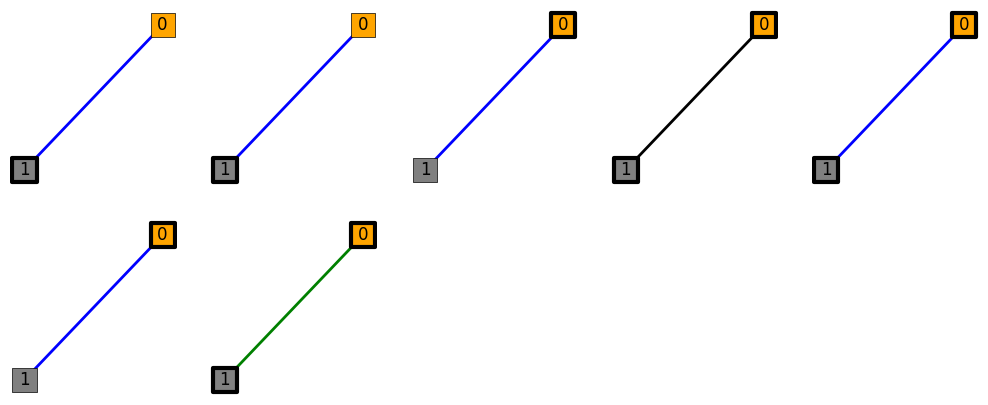

In [12]:
fig, axes = plot_list_of_graphs(irreducibles_bb, optimizer_search.space,
                                node_colors=["orange", "gray"])
plt.show()


The spectrum of every irreducible device, so the flat band can be compared across
architectures rather than read off a single solution:

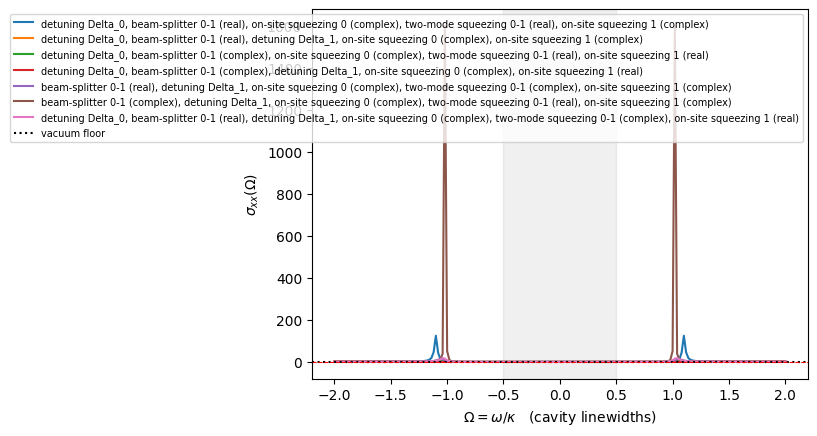

In [13]:
for graph in sorted(irreducibles_bb, key=lambda g: int(np.sum(g))):
    solution = optimizer_search.solution_of(graph)
    if solution is None:
        ok, infos = optimizer_search.test_graph(graph, num_tests=20)
        if not ok:
            continue
        solution = infos[-1]
    spectrum = np.array([np.real(optimizer_search.oracle.covariance(solution["x"], w)[0, 0])
                         for w in omegas])
    plt.plot(omegas, spectrum, "-",
             label=", ".join(optimizer_search.space.describe(graph)))

plt.axhline(1.0, color="k", ls=":", label="vacuum floor")
plt.axhline(0.5, color="r", ls="--", lw=0.8)
plt.axvspan(-BANDWIDTH, BANDWIDTH, color="k", alpha=0.06)
plt.xlabel(r"$\Omega = \omega/\kappa$   (cavity linewidths)")
plt.ylabel(r"$\sigma_{xx}(\Omega)$")
plt.legend(fontsize=7, loc="upper right")
plt.show()